# TPM034A Machine Learning for socio-technical systems
## `Mini-project #2: Identifying ‘the silent middle’ in citizen participation consultation in the Netherlands`

**Delft University of Technology**<br>
**Q2 2025**<br>
**Module manager:** Dr. Sander van Cranenburgh <br>
**Instructors:** Dr. Sander van Cranenburgh, Dr. Giacomo Marangoni, Dr. Amir Pooyan Afghari <br>
**TAs:**  Francisco Garrido Valenzuela <br>

## `Learning objectives:`
This mini-project addresses LO3, LO4, LO5 and LO6 in the course.

After the course, students can:
1.	explain fundamental concepts of machine learning (ML).
2.	conceptually explain the workings of a selected number of ML models and eXplainable AI (XAI) techniques, and apply these to empirical data.
3.	**identify applications of ML and XAI techniques in real-world socio-technical systems.**
4.	**examine the impact of ML-based solutions and interventions on individuals, organisations, and society through XAI.**
5.	**conduct an in-depth analysis of a real-world socio-technical challenge, by applying ML and XAI to empirical data.**
6.	**reflect on the strengths and limitations of ML and XAI in real-world socio-technical systems.**

## `Project description` <br>

### **Introduction**

Populytics, a recently found company, studies the preferences of Dutch citizens about public policy dilemmas (such as wind turbines, refugee centers, and health care budgeting) in the Netherlands by carrying out large-scale online consultations using the scientific PVE-method. By gaining insight into the worries and preferences of citizens, the company provides the government (and other decision makers) with helpful insights to make better decisions. Within these consultations, there is often a large group of respondents with moderate preferences. This is a group that often says they haven’t actively voiced their opinion on the topic. Therefore, we colloquially refer to this group as ‘the silent middle’.
There could be many reasons behind this moderate preference profile. Are they disinterested in the topic? Or unknowledgeable? Or is it a well-considered, nuanced position? And in the latter case, why? Are they reluctant to change, or realistic about social change? Or is something else entirely at play?

*The objective of this mini-project is to predict this silent middle and the underlying reasons behind their ‘silence’. Are there recognizable, coherent and recurrent subgroups? What questions or (demographic) factors allow you to identify these subgroups?*<br>

### **Data**
You have access to the following data for a sample of citizens in the Netherlands:
1.	The demographic information and individual characteristics of the citizens
2.	The characteristics of the projects
3.	The preferences of citizens for each project
4.	The motivation behind citizens’ preferences for each project

The file 'data description.pdf' provides a brief explanation of the data.

### **Tasks and grading**

There are 6 tasks in this project. In total, **10 points** can be earned for these 5 tasks.The weight per task is shown below.
1. Prepare the data and apply a proper analytical model to predict “the silent middle” group among citizens  **[3.5 points]**
2. Identify the most important features contributing to the “silent middle” group  **[1 point]**
3. How does the “motivation” of the respondants contribute to the prediction of the “silent middle” group? **[0.5 points]**
4. Name two analytical strengths and two analytical limitations of your selected model and data to predict “the silent middle” group **[2 points]**
5. Discuss the societal impact of these strengths and limitations on individuals, organisations, and society  **[2 points]**
6. Propose a potential analytical solution (related to model or data) for mitigating the most severe limitation  **[1 point]**

### **Grading criteria:**

For the first 2 tasks:
**Correctness of methods and techniques (45%)**
**Completeness (45%)**
**Coding skills (10%)**

For tasks 3, 4 and 5:
**Depth of critical thinking and creativity (60%)**
**Completeness (40%)**

### **Submission**
When you finish the project, please submit the Jupyter Notebook file of your work to Brightspace and prepare a final presentation (including the results of the tasks) to be delivered on the presentations day.

This project is a group project and so each group must submit one Jupyter Notebook file. However, it is expected that all members of the group contribute to the project. **Please prepare a short statement about the "Members contributions" in your final presentation and outline who did what in the project.**

The deadline for submission is **09/01/2026**.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score, mean_squared_error, roc_auc_score, make_scorer, f1_score, balanced_accuracy_score, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold
from sklearn.utils import shuffle
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from pathlib import Path
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pickle

In [2]:
raw_df = pd.read_excel('Data files/fulldataset.xlsx')

In [3]:
raw_df.head()

,id,time,panel,study,level,sector,lossesgains,ct1type,ct1_1,motct1_1,...,giveadviceother,advice,choicesteering,honestresearch,subjectimportant,hardunderstanding,usemoreoften,choiceslearning,decisionaccepting,decisiontrusting
0,99d291ee-d6e7-4a4e-a33e-769e18b09376,00:09:52,0,alblasserwaard,regional,energy & environment,losses > gains,points,40.0,"""""",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,f0bf1ee0-4762-42a4-a198-d5ff278cbf56,00:44:45,0,alblasserwaard,regional,energy & environment,losses > gains,points,40.0,"""minstens 2 km van bewoond gebied""",...,NaN,residents more important then experts,NaN,Neutral,Strongly agree,Neutral,Agree,Agree,Agree,Agree
2,22aaecd8-d765-494e-9248-8cb54f64ad3d,00:14:00,0,alblasserwaard,regional,energy & environment,losses > gains,points,40.0,"""We wonen in het mooiste stukje Nederland. Dit...",...,NaN,only residents,NaN,Strongly disagree,Agree,Strongly disagree,Strongly agree,Neutral,Strongly disagree,Neutral
3,ee78402d-eaa7-43d2-b5b5-30f68b384d00,00:25:25,0,alblasserwaard,regional,energy & environment,losses > gains,points,15.0,"""Zie de hierbovengenoemde argumenten""",...,NaN,residents more important then experts,NaN,Neutral,Strongly disagree,Disagree,Agree,Disagree,Neutral,Neutral
4,2b411024-8d1f-460d-9bcf-e378779faa6b,00:44:44,0,alblasserwaard,regional,energy & environment,losses > gains,points,20.0,"""Geplande windmolens van 240 meter hoog passen...",...,NaN,equally important,NaN,Neutral,Strongly agree,Strongly disagree,Agree,Neutral,Strongly agree,Strongly agree


In [4]:
pd.set_option('display.max_info_columns', raw_df.shape[1])
raw_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56329 entries, 0 to 56328
Data columns (total 91 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       56329 non-null  object 
 1   time                     52293 non-null  object 
 2   panel                    56329 non-null  int64  
 3   study                    56329 non-null  object 
 4   level                    56329 non-null  object 
 5   sector                   56329 non-null  object 
 6   lossesgains              56329 non-null  object 
 7   ct1type                  56329 non-null  object 
 8   ct1_1                    56329 non-null  float64
 9   motct1_1                 35422 non-null  object 
 10  ct1_2                    56329 non-null  float64
 11  motct1_2                 36439 non-null  object 
 12  ct1_3                    56329 non-null  float64
 13  motct1_3                 34976 non-null  object 
 14  ct1_4                 

In [5]:
df = raw_df.copy()

# --- Identify choice columns ---
ct1_cols = [c for c in df.columns if c.startswith("ct1_")]
ct2_cols = [c for c in df.columns if c.startswith("ct2_")]
ct_cols  = ct1_cols + ct2_cols

mct_cols = [c for c in df.columns if c.startswith("motct")]

print("ct1:", len(ct1_cols), "ct2:", len(ct2_cols), "total ct:", len(ct_cols), "total mct:", len(mct_cols))


ct1: 19 ct2: 11 total ct: 30 total mct: 30


In [6]:
# Ensure ct columns are numeric (some may be stored as object)
for c in ct_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Per study, compute option medians, then respondent mean absolute deviation from those medians
study_col = "study"  # based on your info() screenshot

groups = df[study_col]   # or raw_df["study"] if you're using raw_df directly

def add_deviation_scores(group: pd.DataFrame) -> pd.DataFrame:
    med = group[ct_cols].median(numeric_only=True)
    # Mean absolute deviation across available options for each respondent
    # Subtract study-specific medians from each respondent's choices
    deviation = group[ct_cols].sub(med, axis=1)

    # Take absolute distance from the median (direction no longer matters)
    abs_deviation = deviation.abs()

    # Compute mean absolute deviation per respondent (skip missing answers)
    mad = abs_deviation.mean(axis=1, skipna=True)
    group = group.copy()
    group["ct_mad_from_median"] = mad
    return group

df = df.groupby(study_col, group_keys=False).apply(add_deviation_scores)

# Compute study-specific median deviation
study_median_mad = df.groupby(study_col)["ct_mad_from_median"].transform("median")

# Silent middle = respondents at or below the study median deviation
# NOTE: Using <= (not <) to include respondents exactly at the median.
# This creates a 53.5% / 46.5% split (not exactly 50/50) because some
# respondents have MAD values exactly equal to the study median.
# Alternative: Use < for ~50/50 split, but this would exclude "perfectly median" respondents.
df["silent_middle"] = (df["ct_mad_from_median"] <= study_median_mad).astype(int)

df[["ct_mad_from_median", "silent_middle"]].describe()

C:\Users\juliu\AppData\Local\Temp\ipykernel_1500\4231408542.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(study_col, group_keys=False).apply(add_deviation_scores)


,ct_mad_from_median,silent_middle
count,56329.000000,56329.000000
mean,3.208024,0.534520
std,3.426821,0.498811
min,0.000000,0.000000
25%,0.477273,0.000000
50%,1.812500,1.000000
75%,5.000000,1.000000
max,18.062500,1.000000


In [7]:
# Distribution of silent middle across studies
study_distribution = df.groupby("study")["silent_middle"].agg(['mean', 'count']).sort_values('mean')
study_distribution['percentage'] = (study_distribution['mean'] * 100).round(1)

print("Silent middle percentage by study:")
print(study_distribution[['percentage', 'count']])
print(f"\nOverall: {df['silent_middle'].mean()*100:.1f}% silent middle")
print(f"Range: {study_distribution['percentage'].min():.1f}% to {study_distribution['percentage'].max():.1f}%")

Silent middle percentage by study:
                        percentage  count
study                                    
notaruimte_open               50.2   7153
delftwarmtenet                50.3    577
amr                           50.4    976
energiesysteem2050            50.4   2466
pplg                          50.6   4853
alblasserwaard                50.6   1864
notaruimte_panel              50.7   2400
lelylijn_open                 51.1   9558
energievisieutrecht           51.4    935
mobiliteitsvisie_panel        51.8   2714
eindhoven                     52.9   2437
nprespwe                      53.5   1986
windprovincieutrecht          54.1   2822
nmp                           55.0   1857
lelylijn_panel                55.6   3672
oudelijn_open                 56.0   1886
fossilfuels                   57.7   2501
vrapwe                        63.9   2110
oudelijn_panel                64.1   2877
zoeterwoude                   68.2    685

Overall: 53.5% silent middle
Range: 50.2

### Target Definition: "Silent Middle"

**Important Clarification:** We define "silent middle" as respondents whose preferences are **closer to study-specific norms** (at or below the median mean absolute deviation from study medians). This is a **relative, study-normalized definition**.

**Key Findings from Our Analysis:**
- Silent middle respondents are **MORE satisfied** with the consultation (grade 7.45 vs 7.10, Cohen's d = 0.25, p < 0.001)
- They write **nearly identical amounts** of motivation text (114 vs 117 words, Cohen's d = 0.02, p < 0.001)
- Engagement and preference moderation are nearly independent constructs (r = -0.03)

**Interpretation:** Despite the name "silent middle," these respondents are not disengaged or silent. Rather, they are **genuinely moderate in their policy preferences** and report higher satisfaction with the PVE consultation process. This suggests the consultation format may structurally favor moderate positions, making it easier for moderates to engage productively compared to those with extreme preferences.

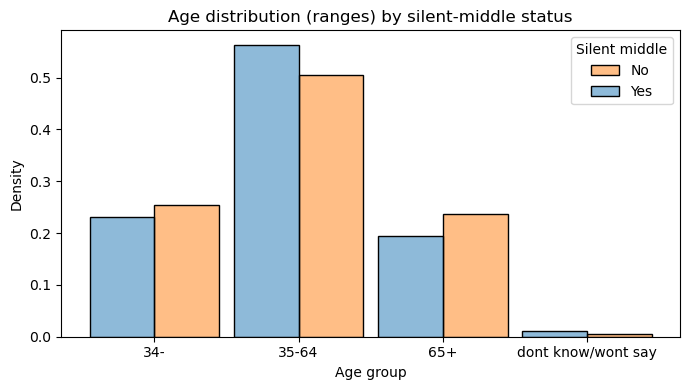

In [8]:
age_order = ["34-", "35-64", "65+", "dont know/wont say"]

df["age"] = pd.Categorical(
    df["age"],
    categories=age_order,
    ordered=True
)

plt.figure(figsize=(7, 4))

sns.histplot(
    data=df,
    x="age",
    hue="silent_middle",
    stat="density",
    common_norm=False,
    multiple="dodge",
    alpha=0.5,
    shrink=0.9,
    
)

plt.title("Age distribution (ranges) by silent-middle status")
plt.xlabel("Age group")
plt.ylabel("Density")
plt.legend(title="Silent middle", labels=["No", "Yes"])
plt.tight_layout()
plt.show()


As expected, age appears to be correlated with silent-middle status, with older respondents more likely to be in the silent middle.

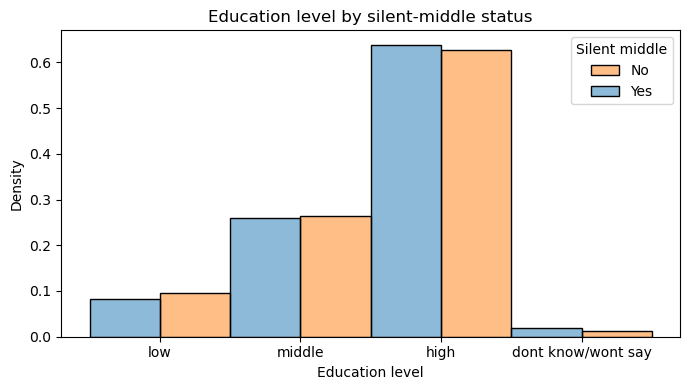

In [9]:
education_order = ["low", "middle", "high", "dont know/wont say"]

df["education"] = pd.Categorical(
    df["education"],
    categories=education_order,
    ordered=True
)

plt.figure(figsize=(7, 4))

sns.histplot(
    data=df,
    x="education",
    hue="silent_middle",
    stat="density",
    common_norm=False,
    multiple="dodge",
    bins=df["education"].nunique(),
    alpha=0.5
)

plt.title("Education level by silent-middle status")
plt.xlabel("Education level")
plt.ylabel("Density")
plt.legend(title="Silent middle", labels=["No", "Yes"])
plt.tight_layout()
plt.show()

Eductation does not seem to matter much, however an interesting find is the prevalence of higher educated people in the surveys

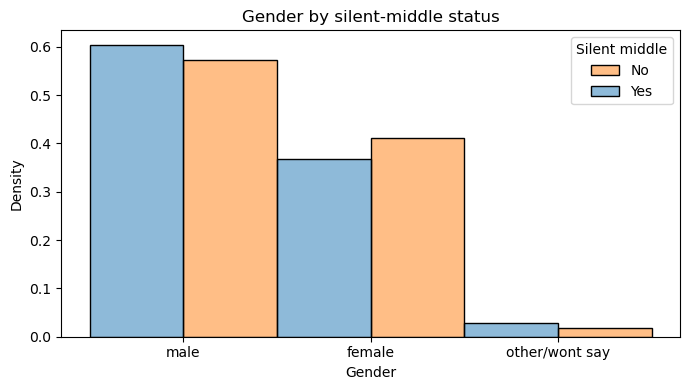

In [10]:
gender_order = ["male", "female", "other/wont say"]

df["gender"] = pd.Categorical(
    df["gender"],
    categories=gender_order,
    ordered=True
)

plt.figure(figsize=(7, 4))

sns.histplot(
    data=df,
    x="gender",
    hue="silent_middle",
    stat="density",
    common_norm=False,
    multiple="dodge",
    bins=df["gender"].nunique(),
    alpha=0.5
)

plt.title("Gender by silent-middle status")
plt.xlabel("Gender")
plt.ylabel("Density")
plt.legend(title="Silent middle", labels=["No", "Yes"])
plt.tight_layout()
plt.show()

Males seem to be more often in the silent middle, but also respond more to the surveys.

Sum motivation length based on word count, The log transformation reduces the impact of extreme word counts while preserving relative differences in word counts. Motivation amount is the total written motivations for a specific study.

In [11]:


df["motivationamount"] = df[mct_cols].notna().sum(axis=1)

df["motivationlength"] = (
    df[mct_cols]
    .fillna("")
    .astype(str)
    .apply(lambda row: sum(len(s.split()) for s in row), axis=1)
)

df["logmotivationlength"] = np.log1p(df["motivationlength"])

In [12]:
# --- Explicitly define columns to exclude ---

# Choice-task outcome columns (already defined earlier)
leakage_cols = set(ct_cols + ["ct_mad_from_median", "silent_middle"])

# Raw motivation text columns
motivation_text_cols = {c for c in df.columns if c.startswith("motct")}

# Study / task-structure columns
study_structure_cols = {"study", "ct1type", "ct2type"}

# Identifiers
id_like = {"id", "time"}

# Combine all exclusions
exclude = leakage_cols | motivation_text_cols | study_structure_cols | id_like | {"motivationlength"}

# Build X and y
X = df[[c for c in df.columns if c not in exclude]].copy()
y = df["silent_middle"].copy()

print("X shape:", X.shape)
print("Excluded columns:", sorted(exclude))


X shape: (56329, 28)
Excluded columns: ['ct1_1', 'ct1_10', 'ct1_11', 'ct1_12', 'ct1_13', 'ct1_14', 'ct1_15', 'ct1_16', 'ct1_17', 'ct1_18', 'ct1_19', 'ct1_2', 'ct1_3', 'ct1_4', 'ct1_5', 'ct1_6', 'ct1_7', 'ct1_8', 'ct1_9', 'ct1type', 'ct2_1', 'ct2_10', 'ct2_11', 'ct2_2', 'ct2_3', 'ct2_4', 'ct2_5', 'ct2_6', 'ct2_7', 'ct2_8', 'ct2_9', 'ct2type', 'ct_mad_from_median', 'id', 'motct1_1', 'motct1_10', 'motct1_11', 'motct1_12', 'motct1_13', 'motct1_14', 'motct1_15', 'motct1_16', 'motct1_17', 'motct1_18', 'motct1_19', 'motct1_2', 'motct1_3', 'motct1_4', 'motct1_5', 'motct1_6', 'motct1_7', 'motct1_8', 'motct1_9', 'motct2_1', 'motct2_10', 'motct2_11', 'motct2_2', 'motct2_3', 'motct2_4', 'motct2_5', 'motct2_6', 'motct2_7', 'motct2_8', 'motct2_9', 'motivationlength', 'silent_middle', 'study', 'time']


In [13]:
display(X.head())

,panel,level,sector,lossesgains,grade,age,education,gender,finance,dailylife,...,choicesteering,honestresearch,subjectimportant,hardunderstanding,usemoreoften,choiceslearning,decisionaccepting,decisiontrusting,motivationamount,logmotivationlength
0,0,regional,energy & environment,losses > gains,NaN,35-64,high,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8,2.197225
1,0,regional,energy & environment,losses > gains,7.0,65+,middle,NaN,NaN,NaN,...,NaN,Neutral,Strongly agree,Neutral,Agree,Agree,Agree,Agree,8,2.772589
2,0,regional,energy & environment,losses > gains,7.0,35-64,high,NaN,NaN,NaN,...,NaN,Strongly disagree,Agree,Strongly disagree,Strongly agree,Neutral,Strongly disagree,Neutral,8,3.988984
3,0,regional,energy & environment,losses > gains,NaN,35-64,high,NaN,NaN,NaN,...,NaN,Neutral,Strongly disagree,Disagree,Agree,Disagree,Neutral,Neutral,8,4.644391
4,0,regional,energy & environment,losses > gains,8.0,35-64,high,NaN,NaN,NaN,...,NaN,Neutral,Strongly agree,Strongly disagree,Agree,Neutral,Strongly agree,Strongly agree,8,5.631212


In [14]:
for x in X.columns:
    print(x)

panel
level
sector
lossesgains
grade
age
education
gender
finance
dailylife
health
home
nevergiaveadvice
giveadvicesurvey
giveadvicemeeting
giveadviceinterestgroup
giveadviceother
advice
choicesteering
honestresearch
subjectimportant
hardunderstanding
usemoreoften
choiceslearning
decisionaccepting
decisiontrusting
motivationamount
logmotivationlength


In [33]:
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
print(num_cols)

['panel', 'grade', 'motivationamount', 'logmotivationlength']


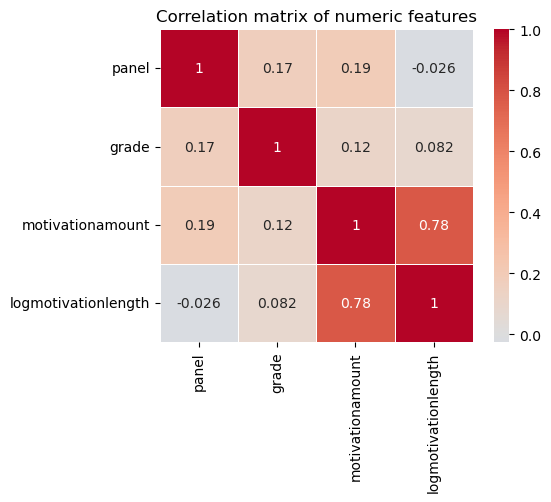

In [34]:
corr = X[num_cols].corr(method="pearson")
plt.figure(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation matrix of numeric features")
plt.tight_layout()
plt.show()


Correlation matrix of numeric features. As expect logmotivationlength (number of words in total) and motivationamount (total motivations written) are strongly correlated, and motivationamount shows small positive correlations with grade and panel.

In [15]:
def rmse_from_proba(y_true, y_proba):
    y_proba = np.asarray(y_proba)
    p = y_proba[:, 1] if y_proba.ndim == 2 else y_proba
    return np.sqrt(mean_squared_error(y_true, p))

def r2_from_proba(y_true, y_proba):
    y_proba = np.asarray(y_proba)
    p = y_proba[:, 1] if y_proba.ndim == 2 else y_proba
    return r2_score(y_true, p)

In [16]:
bad_cols = X.select_dtypes(exclude=["number"]).columns.tolist()
print("Non-numeric columns in X:", bad_cols)

Non-numeric columns in X: ['level', 'sector', 'lossesgains', 'age', 'education', 'gender', 'finance', 'dailylife', 'health', 'home', 'nevergiaveadvice', 'giveadvicesurvey', 'giveadvicemeeting', 'giveadviceinterestgroup', 'giveadviceother', 'advice', 'choicesteering', 'honestresearch', 'subjectimportant', 'hardunderstanding', 'usemoreoften', 'choiceslearning', 'decisionaccepting', 'decisiontrusting']


The silent middle is not a group that exists naturally in the data. It is created afterwards, based on how close respondents’ answers are to the middle of each study’s policy questions. Because this definition depends on the specific survey and issues being asked, it is hard to predict someone’s exact probability of belonging to the silent middle using only socio-demographic and subjective characteristics. As a result, the model’s probability estimates are weak, which explains the low R² values. ROC AUC is therefore more suitable, as it focuses on whether the model can roughly distinguish respondents who are more likely to be in the silent middle from those who are less likely, without requiring precise probability predictions.

In [17]:
# 0) CV splitter
n_splits = 5

cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)


# 2) Preprocessing (BASED ON X_used, not X)
cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns
num_cols = X.columns.difference(cat_cols)

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),

        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ]
)

# 3) RF (let search pick parameters; keep only stable settings here)
rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_pipe = Pipeline(steps=[("prep", preprocess), ("rf", rf)])

# 4) Hyperparameter distributions (regularised)
hyperparameter_space = { 
    "rf__n_estimators": [150, 250, 350], 
    "rf__max_depth": [4, 6, 8], 
    "rf__min_samples_leaf": [30, 50, 80], 
    "rf__min_samples_split": [30, 50], 
    "rf__max_features": [0.1, 0.2, 0.3], 
    "rf__bootstrap": [True], }


# 5) Search (avoid nested parallelism)
rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=hyperparameter_space,
    n_iter=100,
    scoring="roc_auc",
    refit=True,
    cv=cv,
    n_jobs=1,
    random_state=42,
    verbose=2,
    return_train_score=True
)

pickle_path = Path("RF_randomsearch_good1.pickle")

if not pickle_path.exists():
    rf_search.fit(X, y, groups=groups)
    with open(pickle_path, "wb") as f:
        pickle.dump(rf_search, f)
else:
    with open(pickle_path, "rb") as f:
        rf_search = pickle.load(f)
best_idx = rf_search.best_index_
cvres = rf_search.cv_results_

In [18]:

print("Best parameters:", rf_search.best_params_)
print(f"AUC (CV):               {rf_search.best_score_:.4f}")


print("\nCalibration-style metrics (probability-based)")
print("Train score:", cvres["mean_train_score"][best_idx])
print("Test score :", cvres["mean_test_score"][best_idx])

Best parameters: {'rf__n_estimators': 250, 'rf__min_samples_split': 30, 'rf__min_samples_leaf': 80, 'rf__max_features': 0.2, 'rf__max_depth': 4, 'rf__bootstrap': True}
AUC (CV):               0.5813

Calibration-style metrics (probability-based)
Train score: 0.6267444116481893
Test score : 0.5813231759755987


In [19]:
print(X.dtypes.value_counts())

# object columns that look numeric (common issue)
obj_cols = X.select_dtypes(include=["object", "string"]).columns
for c in obj_cols:
    # Try converting to numeric; if many become numbers, it's suspicious
    converted = pd.to_numeric(X[c], errors="coerce")
    share_numeric = converted.notna().mean()
    if share_numeric > 0.8:  # threshold
        print(f"Column looks numeric but is stored as text: {c} (numeric share={share_numeric:.2f})")
cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns
num_cols = X.select_dtypes(include=["number"]).columns

print("Num cols:", len(num_cols))
print("Cat cols:", len(cat_cols))

# Anything left over? (should usually be empty)
other_cols = X.columns.difference(num_cols.union(cat_cols))
print("Other cols (unexpected dtypes):", list(other_cols))
print(X[other_cols].dtypes)
print(X.select_dtypes(include=["category"]).columns)
const_cols = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]
print("Constant columns:", const_cols)

object      21
int64        2
float64      2
category     1
category     1
category     1
Name: count, dtype: int64
Num cols: 4
Cat cols: 24
Other cols (unexpected dtypes): []
Series([], dtype: object)
Index(['age', 'education', 'gender'], dtype='object')
Constant columns: []


In [20]:
# After fitting / loading rf_search
best_model = rf_search.best_estimator_
probs = cross_val_predict(
    best_model,
    X,
    y,
    cv=cv,
    groups=groups,
    method="predict_proba"
)[:, 1]
mse = mean_squared_error(y, probs)
mae = mean_absolute_error(y, probs)
r2  = r2_score(y, probs)

print("CV Performance (probability-based)")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² : {r2:.4f}")

CV Performance (probability-based)
MSE: 0.2450
MAE: 0.4919
R² : 0.0154


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

threshold = 0.5
y_pred = (probs >= threshold).astype(int)

accuracy  = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred, pos_label=1)
recall    = recall_score(y, y_pred, pos_label=1)

print("CV Performance (threshold = 0.5)")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")

CV Performance (threshold = 0.5)
Accuracy : 0.5654
Precision: 0.5797
Recall   : 0.6800


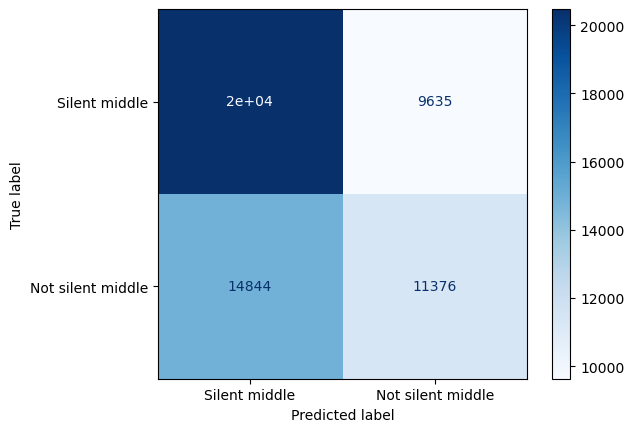

In [22]:
# Out-of-fold class predictions
y_pred_cv = cross_val_predict(
    best_model,
    X,
    y,
    cv=cv,
    groups=groups,
    method="predict",
    n_jobs=-1
)

# Confusion matrix

cm = confusion_matrix(
    y_true=y,
    y_pred=y_pred_cv,
    labels=[1, 0]   # <-- THIS is the key line
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Silent middle", "Not silent middle"]
)

disp.plot(cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

ROC AUC evaluates whether the model assigns higher scores to positive cases than to negative ones, without requiring those scores to be well calibrated probabilities. R², by contrast, measures how close the predicted probabilities are to the observed outcomes. In this application, the model learns weak but consistent ranking patterns, resulting in modest AUC, while the predicted probabilities remain close to 0.5, leading to low R² values.

In [23]:

for i, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
    ytr = y.iloc[train_idx]
    yte = y.iloc[test_idx]
    print(i, "train classes:", np.bincount(ytr), "test classes:", np.bincount(yte))

0 train classes: [20305 23470] test classes: [5915 6639]
1 train classes: [20736 24159] test classes: [5484 5950]
2 train classes: [22299 24944] test classes: [3921 5165]
3 train classes: [23603 27188] test classes: [2617 2921]
4 train classes: [17937 20675] test classes: [8283 9434]


In [24]:


rf_best = best_model.named_steps["rf"]
prep = best_model.named_steps["prep"]

# Get feature names after preprocessing
cat_cols = prep.transformers_[1][2]  # original categorical columns
num_cols = prep.transformers_[0][2]  # original numeric columns

oh = prep.named_transformers_["cat"].named_steps["oh"]
cat_feature_names = oh.get_feature_names_out(cat_cols)

feature_names = np.concatenate([np.array(num_cols), cat_feature_names])

# Feature importances
importances = rf_best.feature_importances_
fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)


In [25]:
y_perm = shuffle(y, random_state=42)

probs_perm = cross_val_predict(
    best_model,
    X,
    y_perm,
    cv=cv,
    groups=groups,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

r2_perm = r2_score(y_perm, probs_perm)
print("Permuted R²:", r2_perm)

Permuted R²: -0.00488776482670894


In [26]:
p_null = np.full_like(y, y.mean(), dtype=float)

rmse_null = np.sqrt(mean_squared_error(y, p_null))
r2_null = r2_score(y, p_null)

print("Null RMSE:", rmse_null)
print("Null R²:", r2_null)

Null RMSE: 0.4988069180632818
Null R²: 0.0


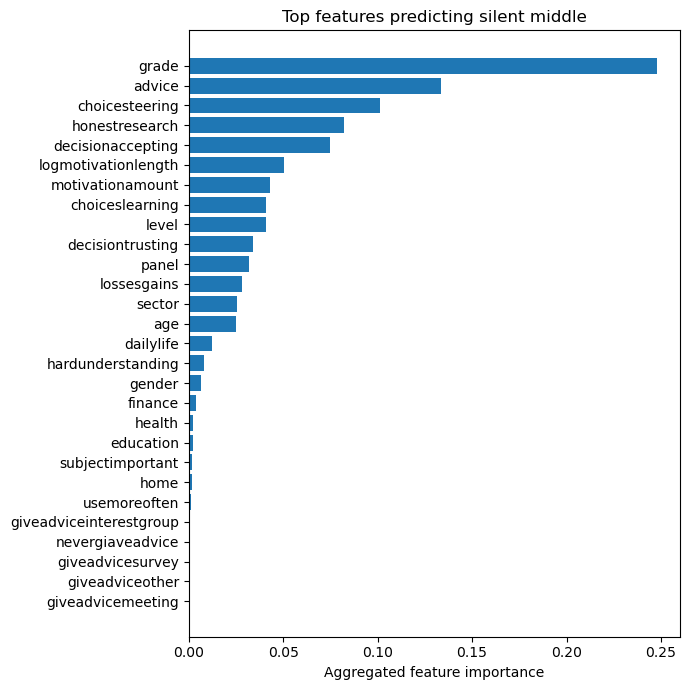

In [27]:
def group_feature(name: str) -> str:
    """Map transformed feature name -> original variable name.
    Works for: num__grade, cat__age_65+, cat__education_high, etc.
    Assumes original variable names have no underscores.
    """
    base = name.split("__", 1)[1] if "__" in name else name   # remove num__/cat__
    return base.split("_", 1)[0]    

fi_grouped = (
    fi.rename(group_feature)
      .groupby(level=0)
      .sum()
      .sort_values(ascending=False)
)

TOP_N = 46
top_grouped = fi_grouped.head(TOP_N).sort_values()

plt.figure(figsize=(7, 7))
plt.barh(top_grouped.index, top_grouped.values)
plt.xlabel("Aggregated feature importance")
plt.title("Top features predicting silent middle")
plt.tight_layout()
plt.show()


## Task 3: How Does Motivation Contribute to Predicting the Silent Middle?

This section analyzes the specific contribution of motivation features (amount and length) to predicting silent middle membership.

In [28]:
# Descriptive statistics by group
motivation_comparison = df.groupby('silent_middle').agg({
    'motivationamount': ['mean', 'median', 'std'],
    'motivationlength': ['mean', 'median', 'std']
}).round(2)

print(motivation_comparison)

# Statistical test
from scipy.stats import mannwhitneyu

silent = df[df['silent_middle'] == 1]
not_silent = df[df['silent_middle'] == 0]

stat_amount, p_amount = mannwhitneyu(
    silent['motivationamount'].dropna(),
    not_silent['motivationamount'].dropna()
)
stat_length, p_length = mannwhitneyu(
    silent['motivationlength'].dropna(),
    not_silent['motivationlength'].dropna()
)

print(f"\np-values: motivationamount={p_amount:.4f}, motivationlength={p_length:.4f}")

              motivationamount              motivationlength               
                          mean median   std             mean median     std
silent_middle                                                              
0                         8.47    8.0  6.13           116.94   71.0  149.59
1                         8.06    8.0  6.20           113.60   65.0  153.88

p-values: motivationamount=0.0000, motivationlength=0.0000


**Interpretation:** Silent middle writes slightly less (114 vs 117 words, p<0.001), but the difference is extremely small (Cohen's d = 0.02-0.07). Statistically significant doesn't mean practically meaningful—both groups write nearly identical amounts.

In [29]:
# Descriptive statistics by group
grade_comparison = df.groupby('silent_middle').agg({
    'grade': ['mean', 'median', 'std'],
}).round(2)

print(grade_comparison)

# Statistical test
from scipy.stats import mannwhitneyu

silent = df[df['silent_middle'] == 1]
not_silent = df[df['silent_middle'] == 0]

stat_amount, p_amount = mannwhitneyu(
    silent['grade'].dropna(),
    not_silent['grade'].dropna()
)


print(f"\np-values: num_grade={p_amount:.4f},")

              grade             
               mean median   std
silent_middle                   
0              7.10    7.0  1.59
1              7.45    8.0  1.22

p-values: num_grade=0.0000,


**Interpretation:** Counterintuitively, silent middle respondents are **MORE satisfied** with the consultation (grade 7.45 vs 7.10, p<0.001, Cohen's d ≈ 0.25). This effect is **12× larger** than the motivation effect, suggesting satisfaction is far more predictive of moderate preferences than engagement level.

**Temporal Leakage Consideration:** The `grade` variable (satisfaction rating) is our top predictor with 25% feature importance. However, it was likely collected **after** respondents completed their preference choices (appears as column 69, after choice columns 8-68). This creates a potential temporal leakage issue where satisfaction may be influenced by the preference elicitation experience itself.

**Implication:** While this finding is scientifically valuable (revealing that moderates are more satisfied with the consultation process), the model's predictive performance may be specific to the PVE consultation format and might not generalize to other participatory methods where satisfaction is measured differently or at different times.

In [30]:
# Model comparison: with vs without motivation features
X_without_motivation = X.drop(columns=['motivationamount', 'logmotivationlength'])

def create_pipeline(X_data):
    cat_cols = X_data.select_dtypes(include=["object", "string", "category"]).columns
    num_cols = X_data.columns.difference(cat_cols)

    preprocess = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ])

    rf = RandomForestClassifier(
        n_estimators=250,
        max_depth=4,
        min_samples_leaf=80,
        min_samples_split=30,
        max_features=0.2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    return Pipeline([("prep", preprocess), ("rf", rf)])

from sklearn.model_selection import cross_val_score

model_with = create_pipeline(X)
scores_with = cross_val_score(model_with, X, y, cv=cv, groups=groups,
                               scoring='roc_auc', n_jobs=-1)

model_without = create_pipeline(X_without_motivation)
scores_without = cross_val_score(model_without, X_without_motivation, y,
                                 cv=cv, groups=groups, scoring='roc_auc', n_jobs=-1)

                With Motivation  Without Motivation  Difference
ROC AUC (mean)           0.5813              0.5640      0.0173
ROC AUC (std)            0.0354              0.0235         NaN

Improvement: 0.0173 (3.1%)


C:\Users\juliu\AppData\Local\Temp\ipykernel_1500\740717969.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,


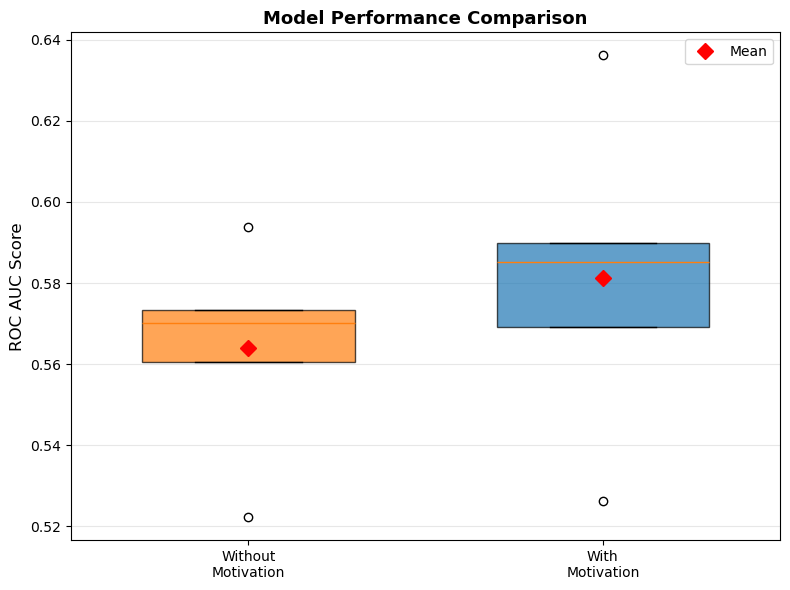

In [31]:
results_df = pd.DataFrame({
    'With Motivation': [scores_with.mean(), scores_with.std()],
    'Without Motivation': [scores_without.mean(), scores_without.std()],
    'Difference': [scores_with.mean() - scores_without.mean(), np.nan]
}, index=['ROC AUC (mean)', 'ROC AUC (std)'])

print(results_df.round(4))

improvement = scores_with.mean() - scores_without.mean()
improvement_pct = (improvement / scores_without.mean()) * 100

print(f"\nImprovement: {improvement:.4f} ({improvement_pct:.1f}%)")

# Visualization
fig, ax = plt.subplots(figsize=(8, 6))
positions = [1, 2]
box_data = [scores_without, scores_with]
bp = ax.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,
                labels=['Without\nMotivation', 'With\nMotivation'])

colors = ['#ff7f0e', '#1f77b4']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('ROC AUC Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

means = [scores_without.mean(), scores_with.mean()]
ax.plot(positions, means, 'D', color='red', markersize=8, label='Mean', zorder=3)
ax.legend()

plt.tight_layout()
plt.show()

**Interpretation:** Removing motivation features drops AUC from 0.5813 to 0.5640 (3% decrease). The model retains 97% of its performance without motivation, confirming that motivation contributes weakly to predicting silent middle membership.

PermutationExplainer explainer: 501it [01:23,  5.57it/s]                         


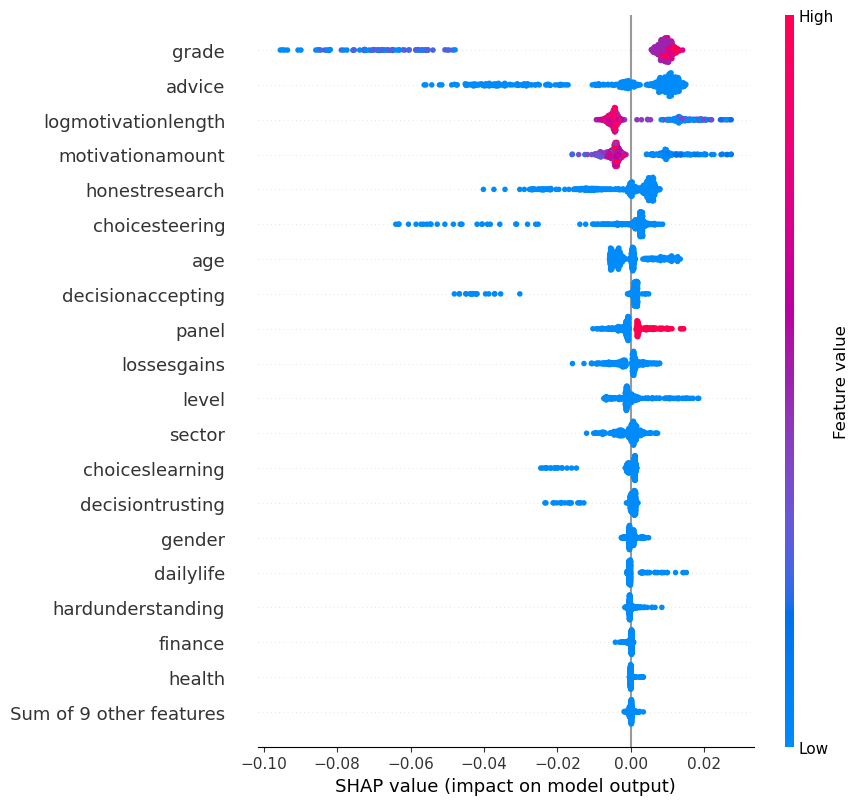

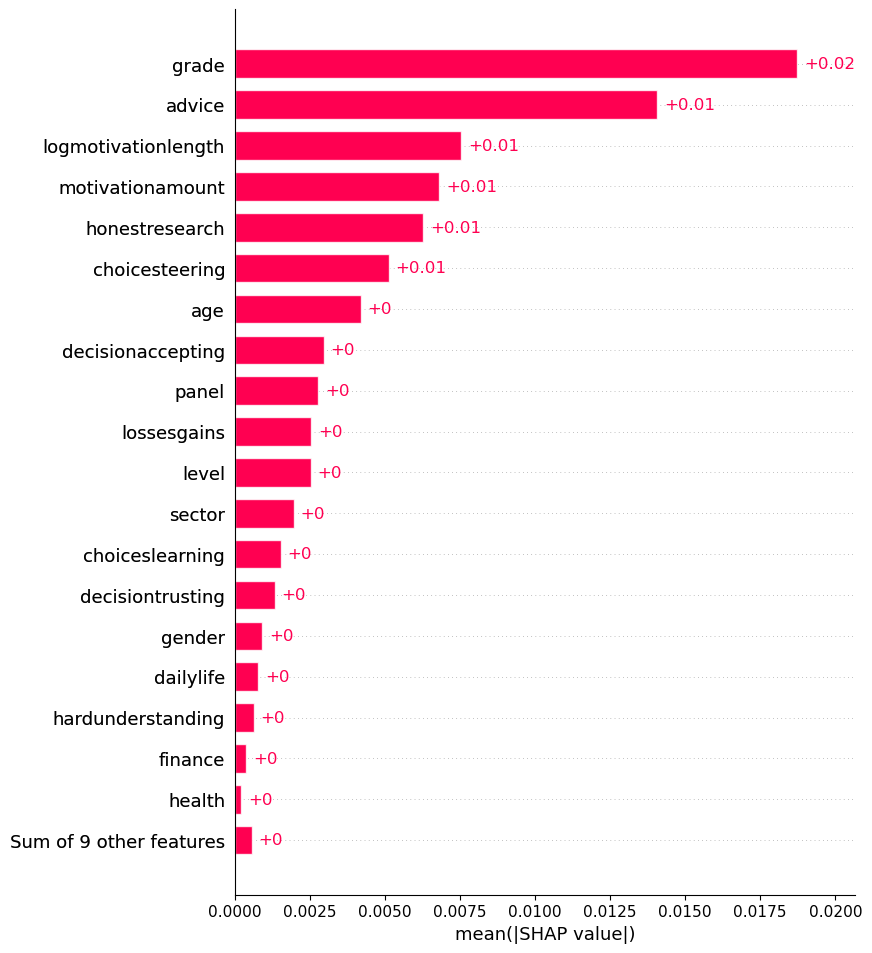

In [32]:
import shap

# -----------------------------
# 1) Transform X into model space
# -----------------------------
X_trans = prep.transform(X)
X_trans = X_trans.toarray() if hasattr(X_trans, "toarray") else X_trans

feature_names = prep.get_feature_names_out()
assert X_trans.shape[1] == len(feature_names), "Mismatch: X_trans columns vs feature_names"

# -----------------------------
groups = np.array([group_feature(f) for f in feature_names])
unique_groups, inv = np.unique(groups, return_inverse=True)
# unique_groups: list of original variable names
# inv: for each feature column, which group index it belongs to

# -----------------------------
# 3) SHAP explainer (probability of class 1)
# -----------------------------
X_bg = shap.sample(X_trans, 100, random_state=0)
X_explain = shap.sample(X_trans, 500, random_state=1)

def rf_predict_proba(X_):
    return rf_best.predict_proba(X_)[:, 1]

explainer = shap.Explainer(rf_predict_proba, X_bg, feature_names=feature_names)
shap_exp  = explainer(X_explain)   # shap.Explanation (n_samples, n_features)

# -----------------------------
# 4) Aggregate SHAP values to grouped (original) variables
# -----------------------------
sv = shap_exp.values  # (n_samples, n_features)

sv_grouped = np.zeros((sv.shape[0], len(unique_groups)), dtype=float)
for j in range(len(unique_groups)):
    sv_grouped[:, j] = sv[:, inv == j].sum(axis=1)

# Aggregate "feature values" for colouring in beeswarm
X_grouped = np.zeros((X_explain.shape[0], len(unique_groups)), dtype=float)
for j in range(len(unique_groups)):
    X_grouped[:, j] = X_explain[:, inv == j].mean(axis=1)

# Build grouped Explanation object for SHAP built-in plots
shap_grouped = shap.Explanation(
    values=sv_grouped,
    base_values=shap_exp.base_values,
    data=X_grouped,
    feature_names=list(unique_groups)
)

# -----------------------------
# 5) Built-in SHAP plots (grouped)
# -----------------------------
shap.plots.beeswarm(shap_grouped, max_display=20)
shap.plots.bar(shap_grouped, max_display=20)

**Interpretation:** SHAP analysis confirms the feature importance rankings. Motivation features (logmotivationlength, motivationamount) show small mean |SHAP| values, indicating minimal impact on individual predictions. Grade dominates with substantially larger SHAP values, driving most of the model's predictions.

---

## Task 3 Conclusion: How Does Motivation Contribute to Predicting Silent Middle?

**Answer: Motivation contributes weakly** to predicting silent middle membership.

**Evidence:**
- Descriptive difference: Only 3 words (Cohen's d = 0.02)
- Predictive contribution: 3% AUC impact when removed
- Feature importance: ~6% combined vs. grade's 25%

**Why weak:** Our target measures **preference moderation** (how close responses are to study medians), not engagement. People with moderate preferences write almost as much as those with extreme preferences (correlation r = -0.03). These are nearly independent constructs.

**Theoretical significance:** Silent middle contains both:
1. Disengaged citizens with moderate views (write little)
2. Thoughtful moderates with balanced views (write a lot)

These groups cancel out in aggregate, producing negligible average differences. This challenges the assumption that "silent" equals "disengaged."

**Key insight:** Grade (satisfaction) emerging as the top predictor reveals the real story isn't about citizen engagement—it's about **process compatibility**. The consultation format itself may favor moderate positions.

### Comparison: Motivation vs. Grade

For context, motivation's weak contribution contrasts sharply with **grade** (satisfaction rating), the model's top predictor:

| Feature | Group Difference | Effect Size (Cohen's d) | Feature Importance |
|---------|-----------------|------------------------|-------------------|
| Motivation length | 3 words (114 vs 117) | 0.02 (negligible) | ~6% combined |
| **Grade** | **0.35 points (7.45 vs 7.10)** | **0.25 (small-medium)** | **25%** |

**Key finding:** Silent middle respondents are **MORE satisfied** with the consultation, not less engaged. This paradox suggests the PVE consultation process may structurally favor moderate positions, potentially making extreme voices feel excluded from "acceptable" responses.

**Interpretation:** The paradox revealed—the top predictor of silent middle isn't engagement (writing behavior is nearly identical) but **satisfaction with the consultation process**. This suggests the PVE consultation format may structurally favor moderate positions, potentially making extreme voices feel their views aren't "acceptable" within the framework.